In [313]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

## To generate new results for the past year

In [3]:
ticker = ["SGOV", "VTWO", "GTLB", "GLXY", "AAPL", "AFRM","SOFI","AMZN","PLTR", "NVDA","BIDU","META","BABA","IREN","TAN","ETHA","DAPP","KLAR","JD"]
stonks = yf.download(ticker, start = datetime.today().date() - timedelta(days=365), end= datetime.today().date())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  19 of 19 completed


In [5]:
stonks.to_csv("myPortfolio12-14-25.csv")

## To show results for 01/01-12/13/2025

In [311]:
stonks = pd.read_csv("myPortfolio12-14-25.csv", header= [0,1], index_col=[0], parse_dates=[0])
close = stonks.loc[:,"Close"].copy()
returns = close.pct_change().iloc[1:, :]
covarianceMatrix=returns.cov()
corrMatrix=returns.corr()

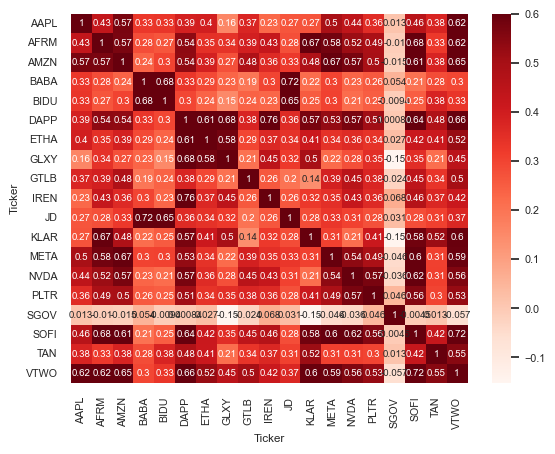

In [315]:
plt.figure(figure=(14, 12))
sns.set(font_scale=0.7)
sns.heatmap(corrMatrix, cmap="Reds", annot=True, annot_kws={"size":7}, vmax =0.6)
plt.show()

### Enter stock values in alpha

In [319]:
alpha = np.array([556.56,538.87,452.38,319.43,366.11,186.20,186.82,591.54,715.44,242.37,147.20,155.50,322.12,397.38,435.62,3440.90,504.32,239.20,1028.10])
portfolioVariance=np.dot(alpha, np.dot(covarianceMatrix.values, alpha))
portfolioSD=np.sqrt(portfolioVariance)
print("Variance: ", portfolioVariance)
print("SD: ",portfolioSD)

Variance:  26704.413855347186
SD:  163.41485200356541


In [321]:
oneDay99VaR=norm.ppf(0.99)*portfolioSD
oneDay99ES=portfolioSD*(np.exp(-(norm.ppf(0.99)**2)/2))/(np.sqrt(2*np.pi)*(1-0.99))
print( "One-Day 99% VaR: ", oneDay99VaR)
print( "One-Day 99% ES: ", oneDay99ES)
print( "YTD 99% VaR: ", oneDay99VaR*np.sqrt(len(returns)))
print( "YTD 99% ES: ", oneDay99ES*np.sqrt(len(returns)))

One-Day 99% VaR:  380.15979354519305
One-Day 99% ES:  435.5355873756078
YTD 99% VaR:  5852.485631329029
YTD 99% ES:  6704.98514132104


In [325]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # required for 3D projection
from matplotlib import cm


In [381]:

def _safe_T(T, eps=1e-8):
    """Clamp T away from 0 to avoid division-by-zero in Greeks."""
    return np.maximum(np.asarray(T, dtype=float), eps)

def d1(S, K, T, r, sigma, q=0.0):
    T_ = _safe_T(T)
    S, K, r, sigma, q = map(np.asarray, (S, K, r, sigma, q))
    return (np.log(S / K) + (r - q + 0.5 * sigma**2) * T_) / (sigma * np.sqrt(T_))

def d2(S, K, T, r, sigma, q=0.0):
    return d1(S, K, T, r, sigma, q) - sigma * np.sqrt(_safe_T(T))

def bs_call(S, K, T, r, sigma, q=0.0):
    D1 = d1(S, K, T, r, sigma, q)
    D2 = d2(S, K, T, r, sigma, q)
    return S * np.exp(-q * _safe_T(T)) * norm.cdf(D1) - K * np.exp(-r * _safe_T(T)) * norm.cdf(D2)

def bs_put(S, K, T, r, sigma, q=0.0):
    D1 = d1(S, K, T, r, sigma, q)
    D2 = d2(S, K, T, r, sigma, q)
    return K * np.exp(-r * _safe_T(T)) * norm.cdf(-D2) - S * np.exp(-q * _safe_T(T)) * norm.cdf(-D1)

# -----------
# Greeks
# -----------
def delta_call(S, K, T, r, sigma, q=0.0):
    return np.exp(-q * _safe_T(T)) * norm.cdf(d1(S, K, T, r, sigma, q))

def delta_put(S, K, T, r, sigma, q=0.0):
    return -np.exp(-q * _safe_T(T)) * norm.cdf(-d1(S, K, T, r, sigma, q))

def gamma(S, K, T, r, sigma, q=0.0):
    T_ = _safe_T(T)
    d1_ = d1(S, K, T, r, sigma, q)
    return (np.exp(-q * T_) * norm.pdf(d1_)) / (S * sigma * np.sqrt(T_))

def vega(S, K, T, r, sigma, q=0.0):
    # Per 1.0 change in sigma. For per 1% (0.01) change, multiply by 0.01.
    T_ = _safe_T(T)
    d1_ = d1(S, K, T, r, sigma, q)
    return S * np.exp(-q * T_) * norm.pdf(d1_) * np.sqrt(T_)

def theta_call(S, K, T, r, sigma, q=0.0, trading_days=252):
    T_ = _safe_T(T)
    d1_ = d1(S, K, T, r, sigma, q)
    d2_ = d2(S, K, T, r, sigma, q)
    term1 = -(S * np.exp(-q * T_) * norm.pdf(d1_) * sigma) / (2 * np.sqrt(T_))
    term2 = -r * K * np.exp(-r * T_) * norm.cdf(d2_)
    term3 = +q * S * np.exp(-q * T_) * norm.cdf(d1_)
    theta_annual = term1 + term2 + term3
    theta_daily  = theta_annual / trading_days
    return theta_annual, theta_daily  # per year, per day

def theta_put(S, K, T, r, sigma, q=0.0, trading_days=252):
    T_ = _safe_T(T)
    d1_ = d1(S, K, T, r, sigma, q)
    d2_ = d2(S, K, T, r, sigma, q)
    term1 = -(S * np.exp(-q * T_) * norm.pdf(d1_) * sigma) / (2 * np.sqrt(T_))
    term2 = +r * K * np.exp(-r * T_) * norm.cdf(-d2_)
    term3 = -q * S * np.exp(-q * T_) * norm.cdf(-d1_)
    theta_annual = term1 + term2 + term3
    theta_daily  = theta_annual / trading_days
    return theta_annual, theta_daily

# --------------------------
# Plotting helper functions
# --------------------------
def surface_plot(X, Y, Z, title, zlabel, cmap=cm.viridis):
    fig = plt.figure(figsize=(10, 7), dpi=150)
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap=cmap, linewidth=0, antialiased=True)
    ax.set_title(title)
    ax.set_xlabel("Underlying Price (S)")
    ax.set_ylabel("Time to Expiry (years)")
    ax.set_zlabel(zlabel)
    fig.colorbar(surf, shrink=0.65, aspect=12)
    plt.tight_layout()
    plt.show()

def contour_plot(X, Y, Z, title, levels=20, cmap="viridis"):
    fig, ax = plt.subplots(figsize=(8, 6), dpi=150, constrained_layout=True)
    cs = ax.contourf(X, Y, Z, levels=levels, cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("Underlying Price (S)")
    ax.set_ylabel("Time to Expiry (years)")
    cbar = fig.colorbar(cs)
    cbar.ax.set_ylabel("Value")
    plt.show()


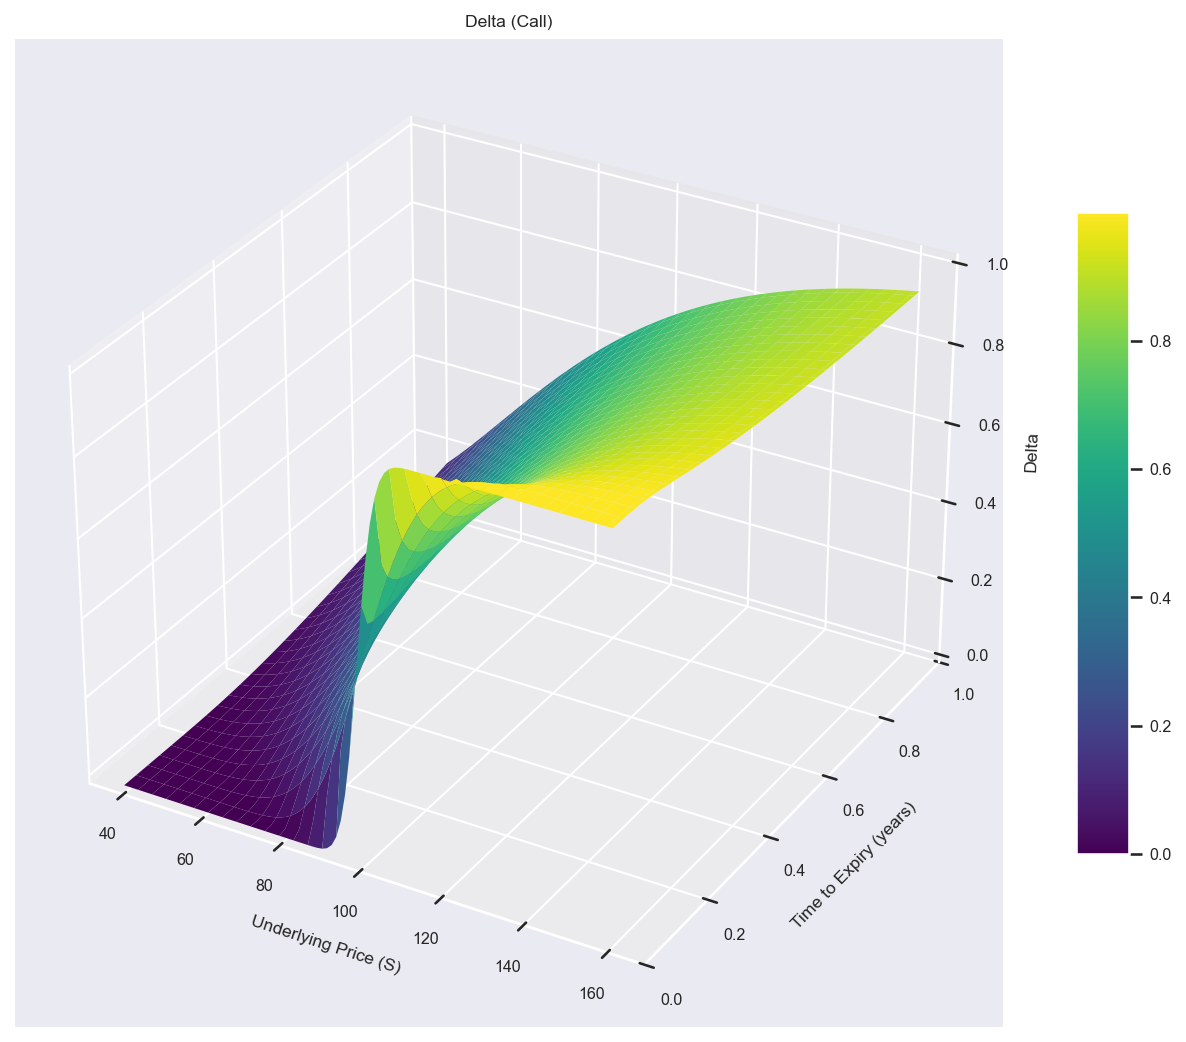

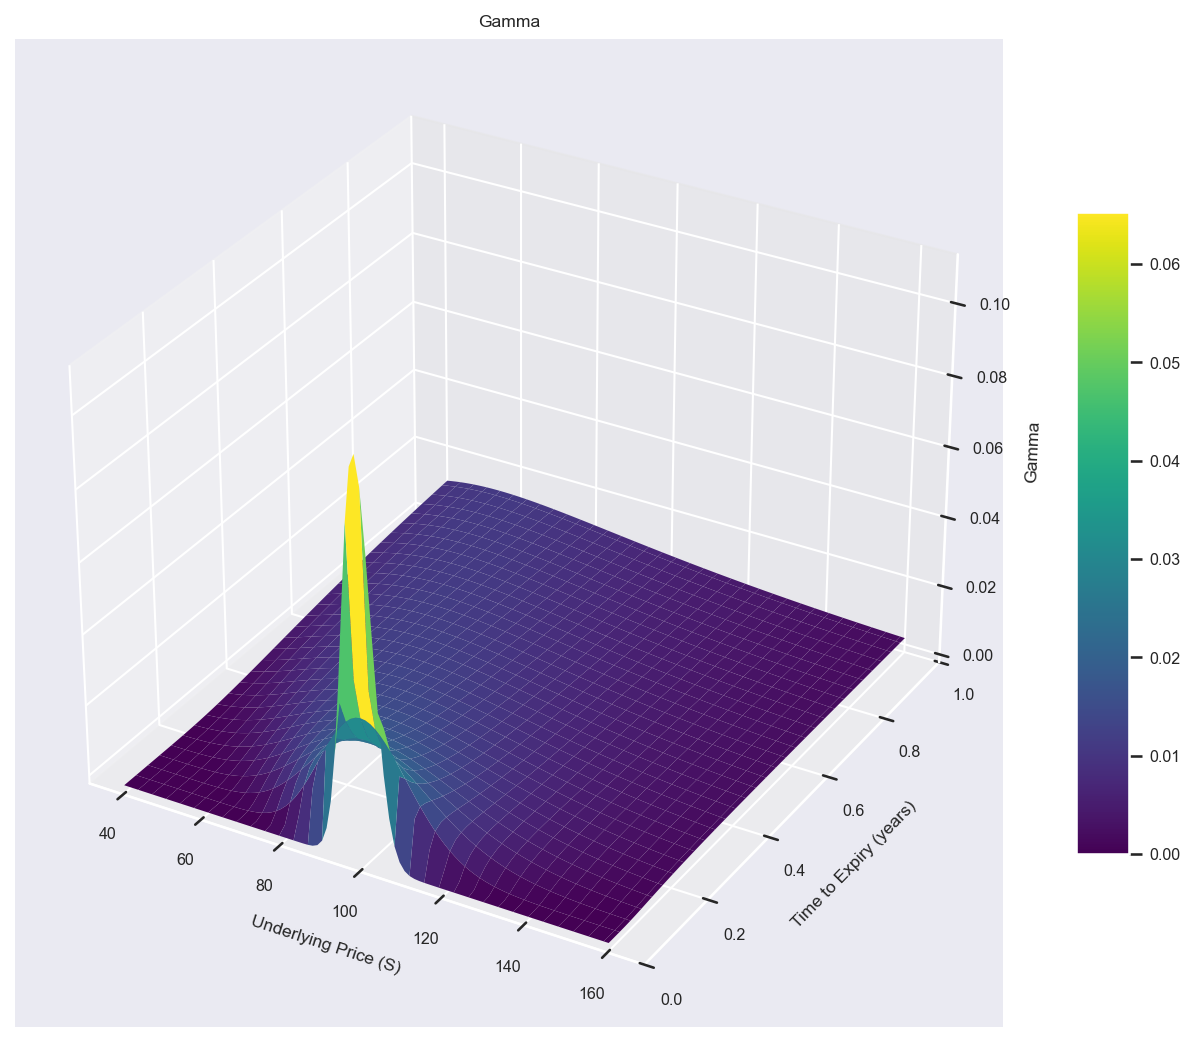

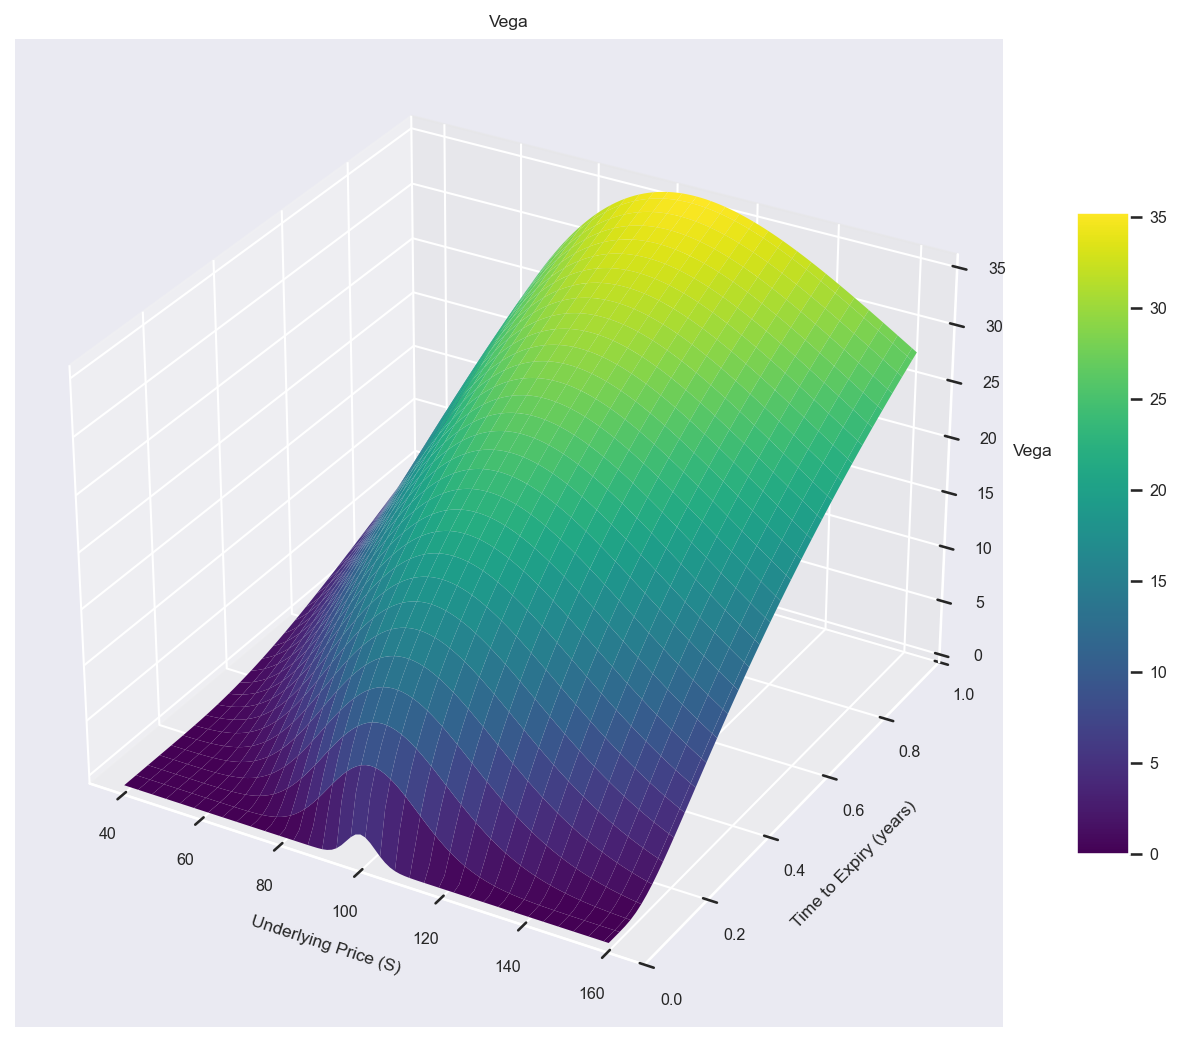

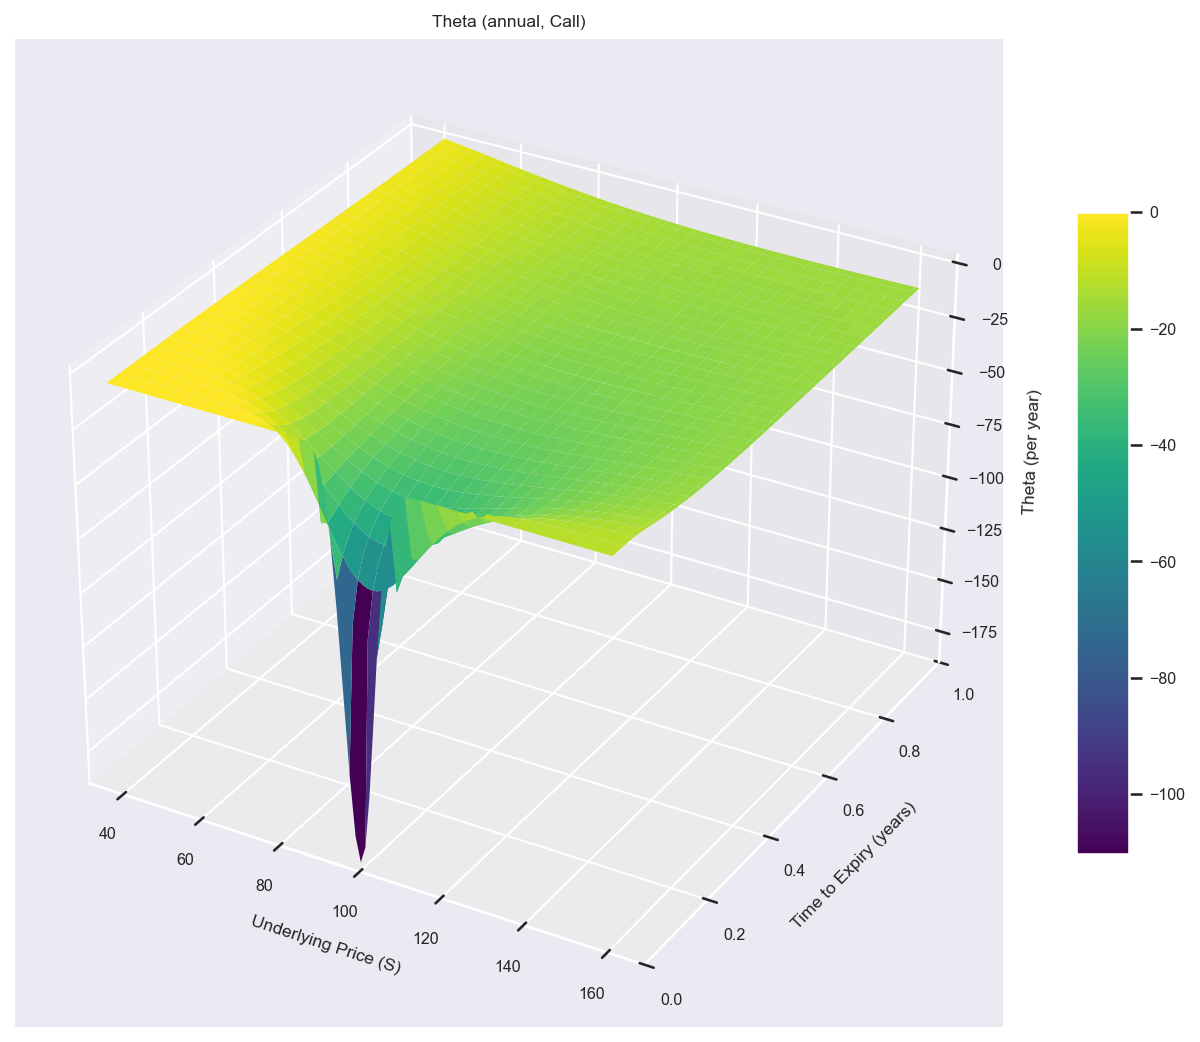

In [389]:

if __name__ == "__main__":
    K = 100.0     # strike
    r = 0.12      # risk-free rate
    sigma = 0.57  # volatility
    q = 0.00      # dividend yield

    # Grid: S from 50 to 150, T from ~1 week to 1y (avoid T=0)
    S_vals = np.linspace(40, 160, 101)
    T_vals = np.linspace(1/252, 1.0, 60)
    S_grid, T_grid = np.meshgrid(S_vals, T_vals)

    Delta = delta_call(S_grid, K, T_grid, r, sigma, q)
    Gamma_ = gamma(S_grid, K, T_grid, r, sigma, q)
    Vega_  = vega(S_grid, K, T_grid, r, sigma, q)
    Theta_y, Theta_d = theta_call(S_grid, K, T_grid, r, sigma, q)

    # 3D surfaces
    surface_plot(S_grid, T_grid, Delta, "Delta (Call)", "Delta")
    surface_plot(S_grid, T_grid, Gamma_, "Gamma", "Gamma")
    surface_plot(S_grid, T_grid, Vega_,  "Vega",  "Vega")
    surface_plot(S_grid, T_grid, Theta_y, "Theta (annual, Call)", "Theta (per year)")